# ZEN Tutorial - Comparing Normalisation Methods

## About

Manually inspecting sample alignment at key loci can be insighful when determining a normalisation method's performance. However, it can be subjective and may not capture systematic differences across the entire genome. This tutorial explains how the package [ZEN-norm](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main) can be used to quantitatively compare performance of normalisation methods genome-wide. For guidance on bigWig normalisation, see the [ZEN Tutorial](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main/tutorials/zen_tutorial).

<a href="https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation"><p><img src="https://raw.githubusercontent.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/refs/heads/assets/Images/ZEN_Overview_Figure.png" style="max-width:1000px" width="100%"></p></a>

**Citation:** [T. Wilson, TA. Milne, SG. Riva and JR. Hughes, _Zone Equalisation Normalisation For Improved Alignment of Epigenetic Signal_, bioRxiv, 2025](https://www.biorxiv.org/content/10.64898/2025.12.10.693203v1)

## Table of Contents

1. [Imports and Set Up](#imports)
2. [Download Example Datasets](#data)
3. [Comparing Normalisation Method Performance Genome-Wide](#norm-compare)

## 1) Imports and Set Up <a id="imports"></a>

Import ZEN-norm modules and other packages, then set global parameters used throughout notebook. 
* If ZEN-norm is not installed, see the [GitHub repository](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main).
* Set `cores` as the number of processors you want to use for parallelisation.

In [ ]:
import os
from ZEN_norm.zone_norm import ZoneNorm
from ZEN_norm.compare_norm import CompareNorm

# Max number of processors to use (set for your system)
cores = 12

## 2) Download Example Datasets <a id="data"></a>

Run `downloadFTP` to download publically hosted ATAC-seq, ChIP-seq and TT-seq BAMs:
* Erythroid day 13 ATAC-seq ([GSE311157](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE311157))
* Erythroid day 13 RAD21 ChIP-seq ([GSE284682](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE284682))
* HeLa control TT-seq ([GSE284682](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE284682))
* HEK293T TT-seq ([GSE218127](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE218127))

In [5]:
# Paths to publicly hosted BAMs and LanceOtron peaks
bam_ftps = {"Erythroid_ATAC": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Public_Data/Human/Erythroid/50_Donors_Erythroid/ZEN_T_Wilson_2026/ATAC/hg38/BAMs/Don{donor}_ATAC_d13_rep{rep}.bam" for donor in ["002", "003"] for rep in range(1,8)],
            "Erythroid_RAD21": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Public_Data/Human/Erythroid/50_Donors_Erythroid/E_Georgiades_2025/RAD21/hg38/BAMs/Don{donor}_RAD21_d13_rep{rep}.bam" for donor in ["001", "002", "030"] for rep in range(1,4) if not (donor == "030" and rep == 2)],
            "HeLa_TTseq": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Public_Data/Human/Cervical_Carcinoma/HeLa_TT-seq_A_Fiszbein_2024/hg38_sacCer3/BAMs/HeLa_TTseq_Control_Rep{rep}.bam" for rep in range(1,4)],
            "HEK293T_TTseq": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Public_Data/Human/Kidney/HEK293T_CA_Mimoso_2023/hg38_dm6/BAMs/HEK293T_TTseq_Rep{rep}.bam" for rep in range(1,5)]}

peak_ftps = {"Erythroid_ATAC": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Public_Data/Human/Erythroid/50_Donors_Erythroid/ZEN_T_Wilson_2026/ATAC/hg38/LanceOtron_Peaks/Don{donor}_ATAC_d13_rep{rep}_L-tron.bed" for donor in
                                ["002", "003"] for rep in range(1,8)],
             "Erythroid_RAD21": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Public_Data/Human/Erythroid/50_Donors_Erythroid/E_Georgiades_2025/RAD21/hg38/LanceOtron_Peaks/Don{donor}_RAD21_d13_rep{rep}_L-tron.bed" for donor in 
                                 ["001", "002", "030"] for rep in range(1,4) if not (donor == "030" and rep == 2)]}

In [24]:
# Download BAMs and peaks per dataset
for data in bam_ftps:
    ZoneNorm.downloadFTP(directory = f"Example_Data/{data}/BAMs",
                         ftp_paths = bam_ftps[data],
                         n_threads = cores,
                         replace_existing = False)
    
for data in peak_ftps:
    ZoneNorm.downloadFTP(directory = f"Example_Data/{data}/LanceOtron_Peaks", 
                         ftp_paths = peak_ftps[data],
                         n_threads = cores,
                         replace_existing = False)

## 3) Comparing Normalisation Method Performance Genome-Wide <a id="norm-compare"></a>

`CompareNorm` provides a quantitive genome-wide signal alignment evaluation approach. The primary method is by Wasserstein distance calculation across signal regions. MA plots across these regions are also supported.

### 3.1) Creating Normalised bigWigs
`CompareNorm` allows any bigWig normalisation method to be compared as either custom or `ZoneNorm` created bigWigs can be provided. Here we show how global library size methods (RPKM, CPM, BPM and RPGC), cross-sample methods (LIB, TMM, RLE) and spike-in normalised (RRPM) bigWigs can created from BAMs. Note that scaling factors for cross-sample methods are extracted from DiffBind in the [DiffBind Tutorial](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main/tutorials/diffbind/DiffBind_Analysis.Rmd).

In [7]:
# Set the BAMs per dataset
test_bams = {"Erythroid_ATAC": "Example_Data/Erythroid_ATAC/BAMs",
             "Erythroid_RAD21": "Example_Data/Erythroid_RAD21/BAMs",
             "HeLa_TTseq": "Example_Data/HeLa_TTseq/BAMs",
             "HEK293T_TTseq": "Example_Data/HEK293T_TTseq/BAMs"}

# Unnormalised
no_norm = ["Raw"]
# Global library size normalisation methods
global_norm = ["RPKM", "CPM", "BPM", "RPGC"]
# Differential accessibility / binding normalisation methods
db_norm = ["LIB", "RLE", "TMM"]
# Spike-in normalisation
spikein_norm = ["RRPM"]
# ZEN normalisation
zen_norm = ["ZEN"]

# Set normalisation methods per dataset, including no normalisation and ZEN
all_norm_methods = {"Erythroid_ATAC": no_norm + global_norm + db_norm + zen_norm,
                    "Erythroid_RAD21": no_norm + global_norm + db_norm + zen_norm,
                    "HeLa_TTseq": no_norm + global_norm + spikein_norm + zen_norm + ["ZEN_Bin_100"],
                    "HEK293T_TTseq": no_norm + global_norm + spikein_norm + zen_norm}

# DiffBind normalisation scaling factors
diffbind_scalars = {"Erythroid_ATAC": {"LIB": [0.7945737, 1.1791765, 1.7767049, 1.4014959, 0.6073187, 0.4475636, 0.9830732, # Donor 2 reps 1-7
                                               0.8167863, 1.2120352, 2.2143716, 0.6942432, 0.5360305, 0.4329880, 0.9036389], # Donor 3 reps 1-7
                                       "RLE": [0.5537296, 0.8202020, 1.3175725, 2.0088472, 0.8326490, 0.6913030, 1.3093021,# Donor 2 reps 1-7
                                               0.6113948, 0.8136031, 1.3829055, 1.3251804, 1.1005014, 0.9012458, 1.7744932], # Donor 3 reps 1-7
                                       "TMM": [0.5047438, 0.7583497, 1.1947526, 1.7916302, 0.7495105, 0.6231320, 1.1663180, # Donor 2 reps 1-7
                                               0.5600562, 0.7563797, 1.2724986, 1.1716478, 0.9743095, 0.8020363, 1.5692559]}, # Donor 3 reps 1-7
                    "Erythroid_RAD21": {"LIB": [0.4386654, 1.2516474, 1.1129529, # Donor 1 reps 1-3
                                                0.7561707, 0.6115422, 1.9099948, # Donor 2 reps 1-3
                                                0.9250313, 0.9939953], # Donor 30 reps 1 and 3
                                        "RLE": [1.100670, 2.443221, 1.507243, # Donor 1 reps 1-3
                                                0.596090, 0.440165, 1.122938, # Donor 2 reps 1-3
                                                1.004272, 1.070815], # Donor 30 reps 1 and 3
                                        "TMM": [0.9010326, 2.0547898, 1.2700094, # Donor 1 reps 1-3
                                                0.5140953, 0.3837037, 0.9555953, # Donor 2 reps 1-3
                                                0.8499643, 0.9103287]}} # Donor 30 reps 1 and 3

# Spike-in organisms per dataset
spike_ins = {"HeLa_TTseq": "sacCer3",
             "HEK293T_TTseq": "dm6"}

Run `ZoneNorm` in a loop with the same output folder and BAMs but for different normalisation methods. This creates separate subdirectories within the results folder per normalisation method.

In [ ]:
# Setting a genome is required for RPGC
genome_size = "hg38"

for data in test_bams:
    bams = test_bams[data]

    if data.endswith("TTseq"):
        # No read extension
        extend_reads = False
        # Split into forward and reverse strand
        filter_strands = ["forward", "reverse"]
    else:
        # Enable read extension
        extend_reads = True
        # Disable spike-in and stand separation
        spikein_prefix = ""
        filter_strands = [None]

    if data in spike_ins:
        # Spike-in organism
        spikein_prefix = spike_ins[data]

    # Create bigWigs for each normalisation method
    for norm in all_norm_methods[data]:
        if norm in db_norm:
            # Use scalar normalisation to create bigWigs multiplied by custom scaling factors
            scaling_factors = diffbind_scalars[data][norm]
            scalar_name = norm
            norm = "Scalar"
        else:
            # Use an inbuilt supported normalisation method, e.g. RPKM
            scaling_factors = {}
            scalar_name = ""

        if norm in no_norm:
            # Set to create unnormalised bigWigs
            norm = None

        for strand in filter_strands:
            znorm = ZoneNorm(analysis_name = data,
                             bam_paths = bams,
                             n_cores = cores,
                             norm_method = norm,
                             extend_reads = extend_reads,
                             spikein_prefix = spikein_prefix,
                             filter_strand = strand,
                             genome_size = genome_size,
                             scaling_factors = scaling_factors,
                             scalar_name = scalar_name)
        
        if norm == "ZEN":
            # Run ZEN normalisation
            znorm.convolveSignals()
            znorm.testDistributions()
            znorm.predictSignalZones()
            znorm.normaliseSignal()

### 3.2) Mapping bigWigs to Samples and Coordinates

`CompareNorm` requires two input CSVs:
1) Normalised bigWig metadata
2) Region coordinates

#### Normalised BigWig Metadata CSV

<ins>Format</ins>

Maps normalised bigWig paths to the normalisation method applied and which sample they come from.

| norm | sample | bigwig |
|------------|-------------| -------------|
| Normalisation method name | Sample name | Path to bigWig |
| ... | ... | ... |

<ins>Helper Method</ins>

If bigWigs are saved within subfolders in the same directory, method `createBigWigFileCSV` can create the CSV using the following parameters. Otherwise, a CSV must be created manually.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`sample_names`** | List or array of sample names. | Required. |
| **`bigwig_directory`** | Directory which contains a subfolder for each normalisation method. | Required. |
| **`norm_methods`** | List or array of normalisation methods. Names must match subfolders in `bigwig_directory`, with the exception of `Raw` which assumes a subfolder named `No_Normalisation`. | Required. |
| **`file_extension`** | Either `.bw` or `.bigWig`. | Required. |
| **`csv_file`** | Set as a file name to save the DataFrame to a CSV. | By default, CSV is returned but not saved. |

#### Region Coordinates CSV

Sets genomic coordinates to evaluate signal alignment over per sample. It can be specified two ways:

##### Option 1: Regions per sample

<ins>Format</ins>

The first option is to create a CSV file containing paths to peak calls, zones (see [ZEN Tutorial](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main/tutorials/zen_tutorial)) or custom coordinates in BED / narrowPeak format per sample. Sample names must match those in the bigWig CSV to link each bigWig to corresponding coordinates.

| sample | regions |
|------------|-------------|
| Sample name | Path to BED or narrowPeaks file |
| ... | ... |

<ins>Helper Method</ins>

A CSV in the above format can be created using method `createRegionsFileCSV`.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`sample_names`** | List or array of sample names, e.g. `["Sample_A", "Sample_B"]`. | Required. |
| **`regions_directory`** | Directory which contains BED or narrowPeak files of coordinates to evaluate alignment over per sample. | Required. |
| **`file_prefix`** | Beginning part of the name of each file, e.g. `padded_zones_` in `padded_zones_sample_A.bed` and `zones_sample_B.bed`. | Set only if file names have a consistent prefix. |
| **`file_postfix`** | End part of the name of each file, e.g. `_peaks` in `sample_A_peaks.narrowPeak` and `zones_sample_peaks.narrowPeak` | Set only if file names have a consistent postfix. |
| **`file_extension`** | Either `.bed` or `.narrowPeak`. | Required. |
| **`csv_file`** | Set as a file name to save the DataFrame to a CSV. | By default, CSV is returned but not saved. |

##### Option 2: Coordinates shared across samples

<ins>Format</ins>

Alternatively, a CSV of custom coordinates can be created. Though this will use the same coordinates for every sample.

| chrom | start | end |
|------------|-------------|-------------|
| Chromosome name | Start coordinate (indexing starts at 0) | End coordinate |
| ... | ... | ... |

#### Creating CSVs for ATAC-seq, ChIP-seq and TT-seq

The bigWig CSV includes paths to all raw and normalised bigWigs per sample. As ATAC-seq and RAD21 ChIP-seq are mostly punctate, regions CSV is set to use pre-created [LanceOtron](https://github.com/LHentges/LanceOtron) peak calls. TT-seq creates diffuse transcriptional signal, so CSVs are set as padded signal zones.

In [ ]:
# Set LanceOtron peak calls for ATAC-seq and ChIP-seq
peak_dirs = {"Erythroid_ATAC": "Example_Data/Erythroid_ATAC/LanceOtron_Peaks",
             "Erythroid_RAD21": "Example_Data/Erythroid_RAD21/LanceOtron_Peaks"}

In [ ]:
# Create dataframes setting the normalised bigWigs to compare and the regions (peaks or zones) to compare them across 
bw_dfs = {}
regions_dfs = {}

for data in test_bams:
    bams = test_bams[data]
    norm_methods = all_norm_methods[data]

    # Create zonenorm object to extract sample names and bigwigs
    znorm = ZoneNorm(analysis_name = data,
                     bam_paths = bams,
                     n_cores = cores,
                     verbose = 0)
    
    sample_names = znorm.getSampleNames()
    bigwig_directory = os.path.join(znorm.getOutputDirectory(), "Results", "BigWigs")

    bw_dfs[data] = CompareNorm.createBigWigFileCSV(sample_names = znorm.getSampleNames(), 
                                                   bigwig_directory = bigwig_directory, 
                                                   norm_methods = norm_methods,
                                                   file_extension = ".bw",
                                                   csv_file = "")
    
    if data in peak_dirs:
        # Create regions CSV using the peak calls per sample
        regions_dfs[data] = CompareNorm.createRegionsFileCSV(sample_names = sample_names,
                                                             regions_directory = peak_dirs[data],
                                                             file_postfix = "_L-tron",
                                                             file_extension = ".bed",
                                                             csv_file = "")
    else:
        # Create regions CSV using the padded signal zones per sample
        regions_dfs[data] = CompareNorm.createRegionsFileCSV(sample_names = sample_names, 
                                                             regions_directory = os.path.join(data, "Results", "BED", "Zones"),
                                                             file_prefix = "padded_zones_",
                                                             file_extension = ".bed")

### 3.3) Creating CompareNorm per Dataset

`CompareNorm` must be initialised using the bigWig metadata and region coordinates CSVs. Several other parameters can be set:

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`analysis_name`** | Custom output folder name. | Recommended. Defaults to saving results to a folder named `Analysis` created in the current working directory. |
| **`bigwig_df`** | How input bigWigs are mapped to the samples they belong to and the normalisation method that was applied. Settable as either a file path to a CSV or as a DataFrame with columns "norm", "sample" and "bigwig", where each row contains the name of the normalisation method, sample name and bigWig path. | Required. |
| **`regions_df`** | To evaluate normalisation performance over regions such as peaks, zones or custom coordinates, set as a DataFrame with columns "sample" and "regions", where regions are given by paths to BED or narrowPeak files. | Required, unless `coords_df` is set. |
| **`coords_df`** | To evaluate normalisation performance over custom coordinates, set as a DataFrame containing "chrom", "start" and "end". Must be given if regions_df is not specified. | Required, unless `regions_df` is set. |
| **`min_peak_score`** | If LanceOtron peaks are given in `regions_df`, this threshold can be set as a value between 0 to 1 to filter peaks by their peak score. A higher value indicates a higher quality threshold and so will filter more peaks. | Only applicable if LanceOtron peaks are input. If not set, no filtering if applied. |
| **`min_consensus`** | Minimum sample number that a region must be present in to be included to evaluate signal alignment per normalisation method. | Defaults to 1 so that all regions are included. Only applicable if `regions_df` was set. |
| **`n_cores`** | Number of processors to use. | Defaults to use one core. |

In [21]:
# Create a compare norm object for each dataset
compare_norms = {}

for data in test_bams:
    norm_methods = all_norm_methods[data]

    # Specify input bigWigs, peaks and parameters for normalisation method comparision
    compare_norms[data] = CompareNorm(analysis_name = data,
                                      bigwig_df = bw_dfs[data],
                                      regions_df = regions_dfs[data],
                                      min_peak_score = 0.5,
                                      min_consensus = 1,
                                      n_cores = cores)

Opening 126 bigWig files
Opening 72 bigWig files
Opening 48 bigWig files
Opening 56 bigWig files


### 3.4) Wasserstein Distance

To quantify genome-wide signal alignment, min-max Wasserstein distance $(w)$ is calculated pairwise between samples across genomic regions. Mix-max scaling to range $[0,1]$ ensures that alignment can be compared across normalisation methods regardless of scale. 

Wasserstein distance distribution plots can be created by method `plotWasserstein`. These are useful to compare samples where signal is expected to be similar, e.g. biological replicates or similar cell types. Calculating $w$ can be slow if using many samples as run time grows quadratically with every additional sample.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`plot_samples`** | List or array of samples to evaluate pairwise alignment between. | All samples are used if not set. |
| **`norm_methods`** | List or array of normalisation methods to create violin plots for. | All normalisation methods are used if not set. |
| **`chromosomes`** | List or array of chromosomes to include in Wasserstein distance calculation over. | All chromosomes are used if not set. |
| **`reference_norm`** | Specify the name of a normalisation method to compare t-test significance of results against. This is represented on the plot as significance stars. | Not required, but recommended to show significance stars. |
| **`use_chrom_maxs`** | Set as `True` to use chromosome-wide maximum values when mix-max scaling signal during wasserstein distance calculation or `False` to use the maximum signal value for each coordinate pair. | Defaults to `False`. |
| **`star_test`** | If reference_norm was given, set this as the statistical test to compare distributions. Significant p-values are plotted as stars above the distributions. Options include: `linear mixed model`, `wilcoxon`, `mann whitney u`, `ks stat`, `t-test`. | Defaults to `linear mixed model` |
| **`log_scale`** | Set as `True` to log transform the y-axis. | Defaults to `False`. |
| **`plot_type`** | Either `violin` or `box` | Defaults to `violin`. |
| **`pdf_name`** | If provided, the plot will be saved as a PDF file with this name. | By default, plot is displayed but not saved. |

In each plot, a violin / box represents the distribution of $w$ across pairwise sample comparisions per normalisation method. Lower $w$ indicates better alignment. Bars between a reference normalisation method (if set) and other methods show statistical significance between the two distributions. Violins are coloured by mean $w$.

#### Erythroid ATAC-seq Example

Wasserstein distance plot and test statistics already exist
Plotting violin plot


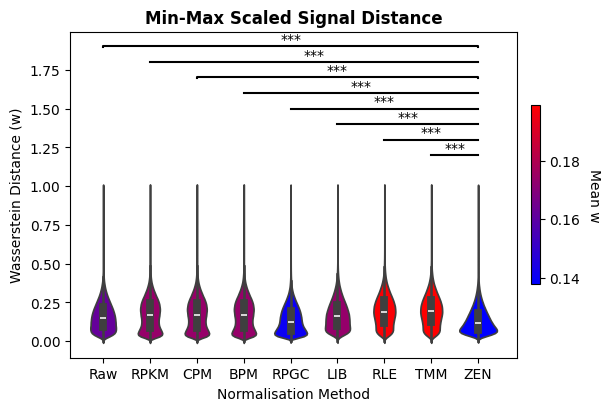

In [6]:
data = "Erythroid_ATAC"
compare_norms[data].plotWasserstein(norm_methods = all_norm_methods[data],
                                    reference_norm = "ZEN",
                                    pdf_name = f"{data}_Wasserstein_Plot")

#### Erythroid RAD21 ChIP-seq Example

Using pre-calculated Wasserstein distances
Wasserstein distance plot and test statistics already exist
Plotting violin plot


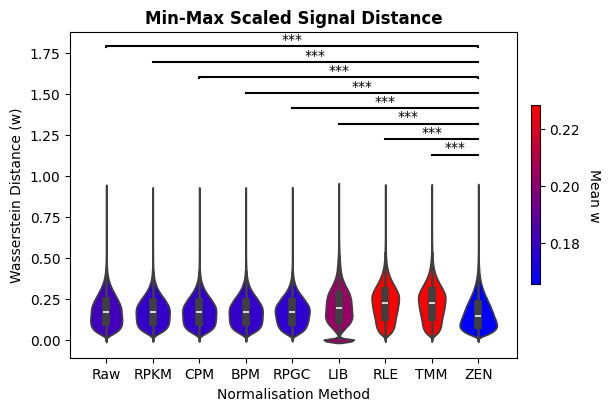

In [26]:
data = "Erythroid_RAD21"
compare_norms[data].plotWasserstein(norm_methods = all_norm_methods[data],
                                    reference_norm = "ZEN",
                                    pdf_name = f"{data}_Wasserstein_Plot")

#### HeLa TT-seq Example

In [8]:
data = "HeLa_TTseq"
hela_compare_norm = compare_norms[data]

# hela_samples_forward = hela_compare_norm.regexFindSamples(regex = "Pos", ignore_case = True)
# hela_samples_reverse = hela_compare_norm.regexFindSamples(regex = "Neg", ignore_case = True)

hela_samples_forward = ["HeLa_TTseq_Control_Rep1_Pos", "HeLa_TTseq_Control_Rep2_Pos", "HeLa_TTseq_Control_Rep3_Pos"]
hela_samples_reverse = ["HeLa_TTseq_Control_Rep1_Neg", "HeLa_TTseq_Control_Rep2_Neg", "HeLa_TTseq_Control_Rep3_Neg"]

Using pre-calculated Wasserstein distances
Wasserstein distance plot and test statistics already exist
Plotting violin plot


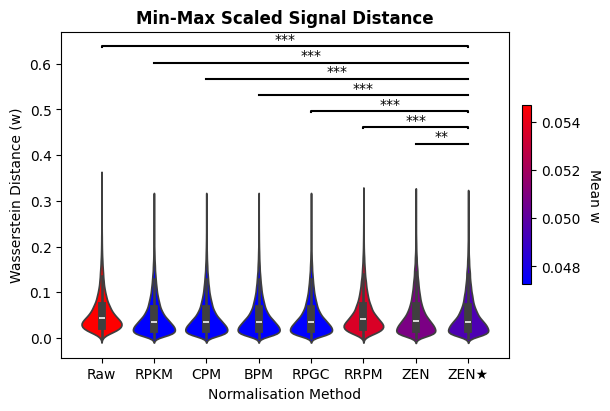

In [12]:
hela_compare_norm.setAnalysisName(f"{data}_Fwd")
hela_compare_norm.plotWasserstein(chromosomes = [],
                                  plot_samples = hela_samples_forward,
                                  norm_methods = all_norm_methods[data],
                                  reference_norm = "ZEN_Bin_100",
                                  custom_norm_names = {"ZEN_Bin_100": "ZEN★"},
                                  pdf_name = f"{data}_Forward_Wasserstein_Plot")

Using pre-calculated Wasserstein distances
Wasserstein distance plot and test statistics already exist
Plotting violin plot


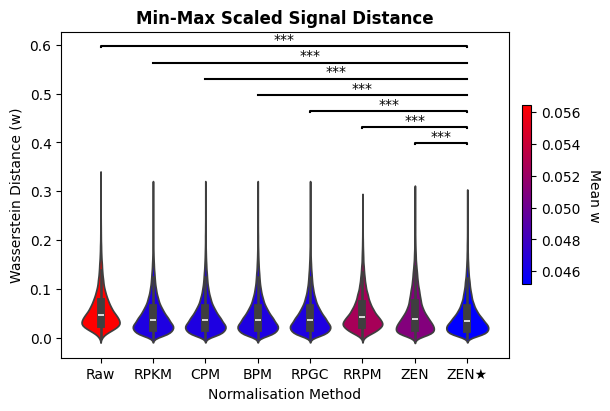

In [14]:
hela_compare_norm.setAnalysisName(f"{data}_Rev")
hela_compare_norm.plotWasserstein(plot_samples = hela_samples_reverse,
                                  norm_methods = all_norm_methods[data],
                                  reference_norm = "ZEN_Bin_100",
                                  custom_norm_names = {"ZEN_Bin_100": "ZEN★"},
                                  pdf_name = f"{data}_Reverse_Wasserstein_Plot")

#### HEK293T TT-seq Example

In [7]:
data = "HEK293T_TTseq"
hek293t_compare_norm = compare_norms[data]

hek293t_samples_forward = hek293t_compare_norm.regexFindSamples(regex = "Pos", ignore_case = True)
hek293t_samples_reverse = hek293t_compare_norm.regexFindSamples(regex = "Neg", ignore_case = True)

Wasserstein distance plot and test statistics already exist
Plotting violin plot


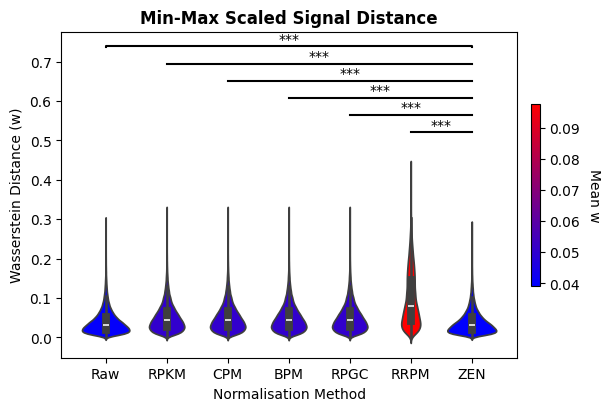

In [8]:
hek293t_compare_norm.setAnalysisName(f"{data}_Fwd")
hek293t_compare_norm.plotWasserstein(chromosomes = [],
                                     plot_samples = hek293t_samples_forward,
                                     norm_methods = all_norm_methods[data],
                                     reference_norm = "ZEN",
                                     pdf_name = f"{data}_Forward_Wasserstein_Plot")

Wasserstein distance plot and test statistics already exist
Plotting violin plot


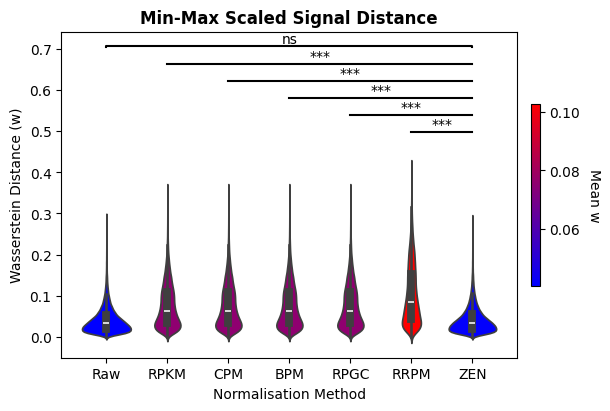

In [9]:
hek293t_compare_norm.setAnalysisName(f"{data}_Rev")
hek293t_compare_norm.plotWasserstein(chromosomes = [],
                                     plot_samples = hek293t_samples_reverse,
                                     norm_methods = all_norm_methods[data],
                                     reference_norm = "ZEN",
                                     pdf_name = f"{data}_Reverse_Wasserstein_Plot")

### 3.5) MA Plots

MA plots created by method `MAPlot` compare differences in total signal (M) relative to signal intensity (A) between sample pairs. For samples and regions that should be similar, e.g. technical replicates, this can be used to assess whether there are biases, e.g. a replice with considerably higher signal.
               
| Parameter | Description | Usage
|------------|-------------|-------------|
| **`norm_method`** | Name of the normalisation method to create the MA plot for. | Required. |
| **`plot_samples`** | List or array of samples to evaluate pairwise similarity between. | All samples are used if not set. |
| **`chromosomes`** | List or array of chromosomes to calculate counts per region over. | All chromosomes are used if not set. |
| **`title`** | Custom title name. | Defaults to no title. |
| **`pdf_name`** | If provided, save the plot to a PDF file with this name. | By default, plot is displayed but not saved. |

In each subplot, a point represents the mean count of the signal over a region's coordinates for two samples. The dotted red line is a reference - the closer the points fall, the closer the average counts are for the samples.

#### HeLa TT-seq Reverse Strand Example

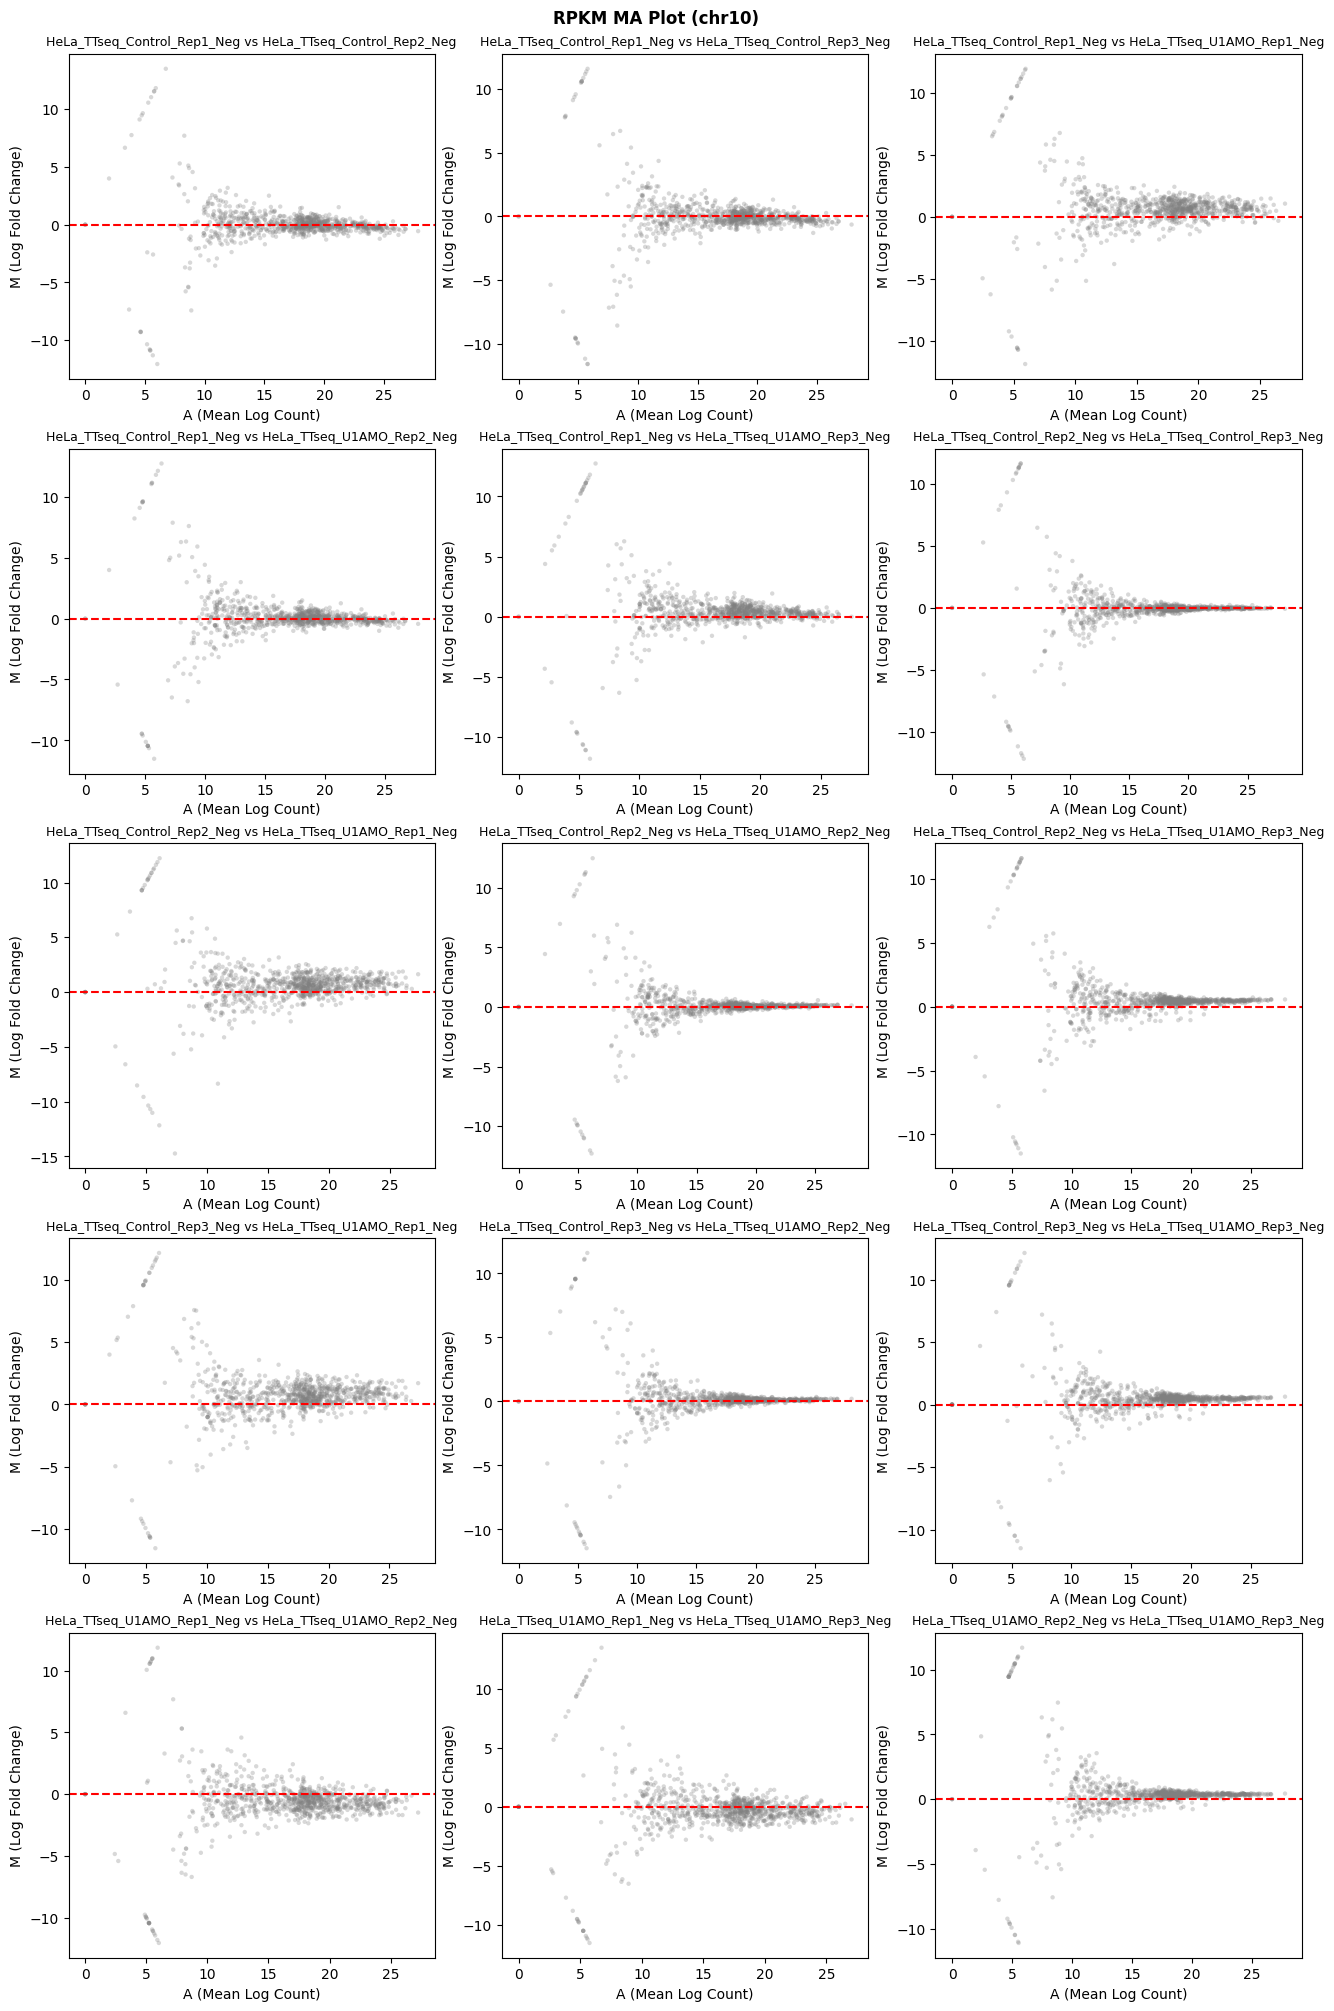

In [ ]:
# Get sample names for reverse strand bigWigs, i.e. names ending in 'Neg'
hela_samples_reverse = hela_compare_norm.regexFindSamples(regex = "Neg", ignore_case = True)

hela_compare_norm.MAPlot(norm_method = "RPKM", 
                         plot_samples = hela_samples_reverse, 
                         chromosomes = ["chr10"],
                         n_cols = 3,
                         plot_width = 13,
                         plot_height = 20)